# **IMPORTS**

In [ ]:
from transformers import AutoModelForImageClassification, AutoProcessor
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import requests
import matplotlib.pyplot as plt
import random
import numpy as np
import sys
import math

# **INITIALISATION**

In [ ]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<function matplotlib.pyplot.show(close=None, block=None)>

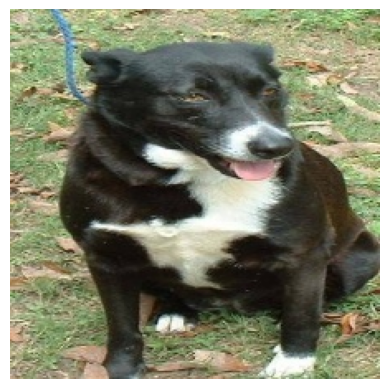

In [ ]:
image = Image.open("/content/sample_data/dog.jpg")

plt.imshow(image)
plt.axis("off")
plt.show

In [ ]:
from transformers import AutoImageProcessor

model_name = "hilmansw/resnet18-catdog-classifier"

model = AutoModelForImageClassification.from_pretrained(model_name).to(device)
model.eval()

# processor = AutoProcessor.from_pretrained(model_name)
# print(processor)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBasicLayer(
              (shortcut): Identity()
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                  (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (activation): ReLU()
           

In [ ]:
# Les Transforms

transformTensor = transforms.ToTensor()

transformPIL = transforms.ToPILImage()

transformIn = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),  # -> je ne suis pas sûr de moi
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalisation -> ImageNet
])

transformOut = transforms.Compose([
    transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
    )
])

# **METHODS**

In [ ]:
def multiple_copies_generator(image, number_of_copies = 40):
    return image.unsqueeze(0).expand(number_of_copies, -1, -1, -1).to(device) # Format [number_of_copies, 3, x, y]

In [ ]:
import torch

def pixel_to_change_generator(image, lower_pourcentage=0.001, upper_pourcentage=0.01):
    _, height, width = image.shape
    random_pourcentage = torch.FloatTensor(1).uniform_(lower_pourcentage, upper_pourcentage).to(device)
    pixel_to_change = (random_pourcentage * (height * width)).floor().int().item()

    return pixel_to_change#, random_pourcentage.item()

In [ ]:
# Genere aleatoirement les valeurs a ajouter sur chaque pixel

def which_pixel_generator_noise(multiple_copies, pixel_to_change, reach = 1, targeted = False, targeted_channel = 0): # reach = 0.1  ->  -0.1 <= x <= 0.1
                                                                                       # RGB -> 0-R; 1-G; 2-B

    batch_size, channels, height, width = multiple_copies.shape

    # Set the location for the pixels to change and for each dimensions -> in64 for indexing
    pixel_c = torch.full((batch_size, pixel_to_change), targeted_channel, dtype=torch.int64).to(device) if targeted else torch.randint(0, channels, (batch_size, pixel_to_change), dtype=torch.int64).to(device)
    pixel_x = torch.randint(0, height, (batch_size, pixel_to_change), dtype=torch.int64).to(device)
    pixel_y = torch.randint(0, width, (batch_size, pixel_to_change), dtype=torch.int64).to(device)

    # Create a tensor with the values to add (+ and -)
    values_to_change = torch.empty(batch_size, pixel_to_change).uniform_(0, reach).to(device) # reach is excluded 0.9999...

    multiple_copies = multiple_copies.clone().to(device)  # Remove if modifying original is okay
    multiple_copies[torch.arange(batch_size).unsqueeze(1), pixel_c, pixel_x, pixel_y] += values_to_change

    return multiple_copies.clamp_(0, 1)

In [ ]:
def parent_generator_fixed(multiple_copies):
    batch_size = multiple_copies.shape[0]
    parents_index = torch.randperm(batch_size, device=device) # shuffle the indexes

    return parents_index

In [ ]:
def crossover_generator(multiple_copies, parents_index, pourcentage_height = 0.15):
  multiple_copies_cross = multiple_copies.clone().to(device)

  batch_size, channels, height, width = multiple_copies.shape

  for i in range(0, len(parents_index), 2):
    parent_index_1 = parents_index[i]
    parent_index_2 = parents_index[i + 1]

    max_size_square = int(multiple_copies.shape[3] * pourcentage_height)  # % hauteur de l'image -> multiple_copies[0].shape[2] prend le nombre de pixel d'une image

    # Swaping zone setting
    which_channel = torch.randint(0, channels, (1,)).to(device)
    size_height = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_height = torch.randint(0, height - size_height + 1, (1,)).to(device)
    size_width = torch.randint(0, max_size_square + 1, (1,)).to(device)
    start_width = torch.randint(0, width - size_width + 1, (1,)).to(device)

    # Swaping
    swap_zone = multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width,].clone()

    multiple_copies_cross[parent_index_1, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = \
        multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width]

    multiple_copies_cross[parent_index_2, which_channel, start_height:start_height + size_height, start_width:start_width + size_width] = swap_zone

  return multiple_copies_cross

In [ ]:
def through_model(multiple_copies):
    # multiple_copies.shape -> (40, 3, 225, 224)
    batch_size = multiple_copies.shape[0]

    # One pic after the other, transformer don't handle 4D
    input_copies = torch.stack([transformIn(multiple_copies[i]).to(device) for i in range(batch_size)])

    with torch.no_grad():  # CNN inputs
        outputs = model(input_copies)

    processed_copies = transformOut(input_copies)

    logits = outputs.logits  # logits -> [40, num_classes]
    probabilities = torch.nn.functional.softmax(logits, dim=-1)

    return probabilities


In [ ]:
def selection(multiple_copies, probabilities, elites, wanted_class, unwanted_class, wanted=True):

    batch_size, channels, height, width = multiple_copies.shape

    probabilities_class = probabilities[:, wanted_class] if wanted else probabilities[:, unwanted_class]
    probabilities_class = probabilities_class.to(device)

    sorted_probabilities, indices = torch.sort(probabilities_class, descending=wanted)
    sorted_probabilities = sorted_probabilities.to(device)
    indices = indices.to(device)

    elites_index = indices[:elites]
    middle_index = indices[elites:batch_size//2]
    low_index = indices[batch_size//2:]

    elites_proba = sorted_probabilities[:elites]
    middle_proba = sorted_probabilities[elites:batch_size//2]
    low_proba = sorted_probabilities[batch_size//2:]

    elites_proba = elites_proba.float()
    middle_proba = middle_proba.float()
    low_proba = low_proba.float()

    elites_selection = multiple_copies[elites_index].to(device)
    middle_selection = multiple_copies[middle_index].to(device)
    low_selection = multiple_copies[low_index].to(device)

    #return elites_selection, middle_selection, low_selection, elites_index, elites_proba
    return elites_selection, middle_selection, elites_index, elites_proba

In [ ]:
def from_rgb_to_ycbcr(tensor_image):
    transform_matrix = torch.tensor([[0.299, 0.587, 0.114],
                                     [-0.169, -0.331, 0.499],
                                     [0.499, -0.460, -0.039]], device=device)

    tensor_image_ycbcr = torch.matmul(transform_matrix, tensor_image.view(3, -1)).to(device)

    # Reshape to have the original pytorch shape for images
    tensor_image_ycbcr = tensor_image_ycbcr.view(3, tensor_image.shape[1], tensor_image.shape[2])

    return tensor_image_ycbcr

In [ ]:
def checker(elites_index, elites_proba, threshold):

    # Search uniquely in elites
    for i in range(len(elites_proba)):
      if elites_proba[i] >= threshold:
        return True, elites_index[i]
      else:
        return False, -1

# **TEST**

50176
29111
torch.Size([40, 3, 224, 224])


<function matplotlib.pyplot.show(close=None, block=None)>

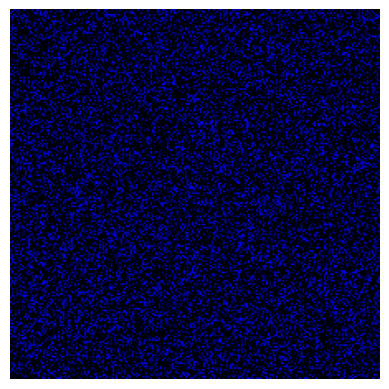

In [ ]:
# Test Noise only

tensor_image = torch.zeros(3, 224, 224)
print(tensor_image.shape[1]*tensor_image.shape[2])
pixel_to_change = pixel_to_change_generator(tensor_image,upper_pourcentage=1)
print(pixel_to_change)
group_tensor_image = multiple_copies_generator(tensor_image, 40)
print(group_tensor_image.shape)

group_tensor_image = which_pixel_generator_noise(group_tensor_image, pixel_to_change, reach=1, targeted=True, targeted_channel=2)

test_image = group_tensor_image[0]

image_restored = transformPIL(test_image)
plt.imshow(image_restored)
plt.axis("off")
plt.show

# **MAIN CODE**

# **1ST APPROACH**
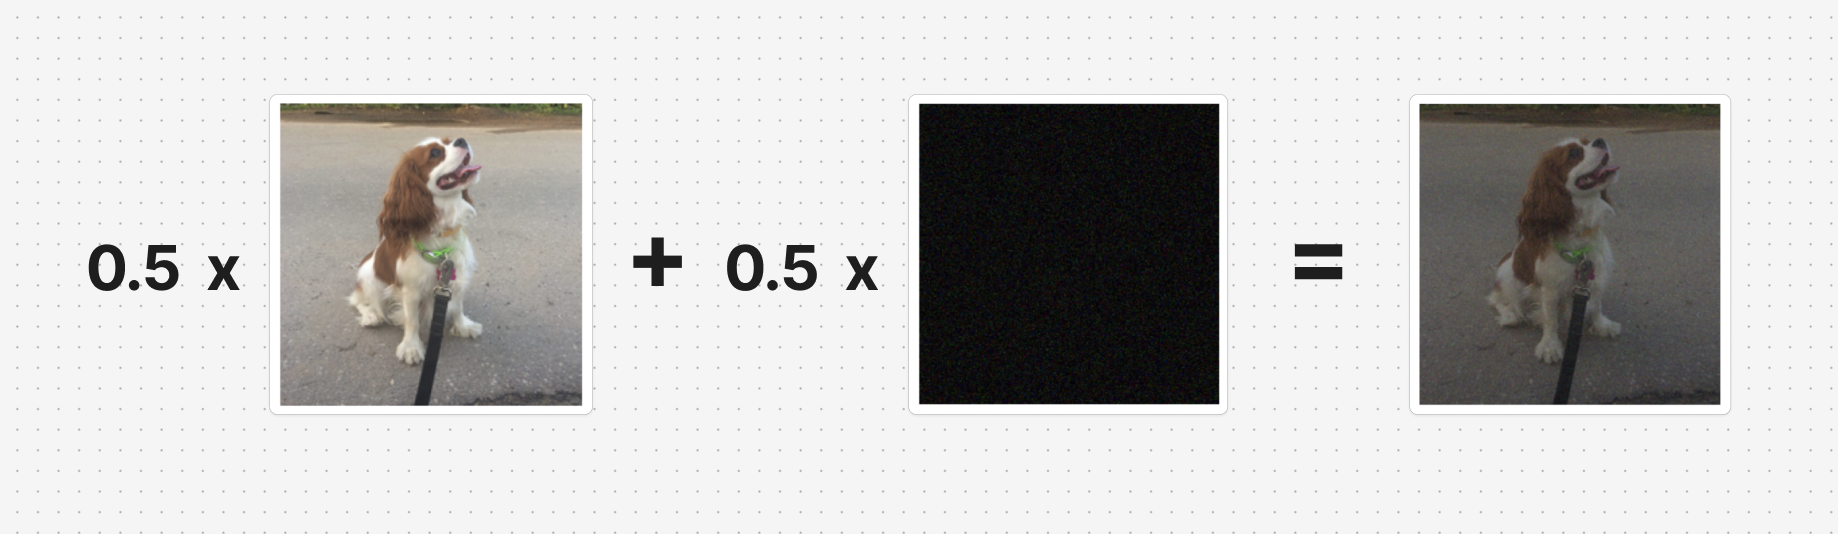

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
0
tensor([0.7676, 0.7667, 0.7613, 0.7609, 0.7616, 0.7609, 0.7615, 0.7619, 0.7585,
        0.7591, 0.7588, 0.7587, 0.7576, 0.7577, 0.7584, 0.7574, 0.7571, 0.7575,
        0.7570, 0.7558, 0.7660, 0.7592, 0.7671, 0.7603, 0.7628, 0.7633, 0.7541,
        0.7558, 0.7613, 0.7687, 0.7640, 0.7544, 0.7556, 0.7609, 0.7682, 0.7540,
        0.7606, 0.7560, 0.7516, 0.7663])
30.40607261657715
1
tensor([0.7686, 0.7686, 0.7674, 0.7678, 0.7649, 0.7660, 0.7658, 0.7639, 0.7636,
        0.7629, 0.7608, 0.7618, 0.7613, 0.7614, 0.7616, 0.7607, 0.7617, 0.7608,
        0.7612, 0.7603, 0.7697, 0.7642, 0.7637, 0.7705, 0.7590, 0.7630, 0.7587,
        0.7658, 0.7642, 0.7697, 0.7514, 0.7623, 0.7613, 0.7592, 0.7680, 0.7541,
        0.7647, 0.7609, 0.7623, 0.7604])
30.5244083404541
2
tensor([0.7697, 0.7697, 0.7693, 0.7686, 0.7686, 0.7681, 0.7678, 0.7673, 0.7660,
        0.7654, 0.76

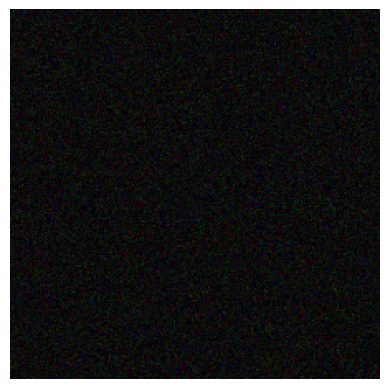

tensor([0.0003])
tensor([0.0025])


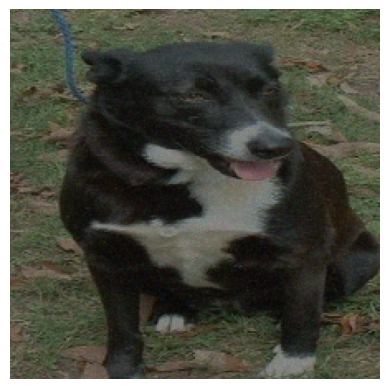

In [ ]:
# 1ST APPROACH

# NOISE VERSION
# WITH NOISE ONLY, NO IMAGES
# ⚙️ HYPERPARAMETERS

# Free GPU cache
torch.cuda.empty_cache()

ENUMS = 1000

WANTED_CLASS = 0
UNWANTED_CLASS = 1 # not used

HEIGHT = 0.15 # significantly increse running time; its the height of the crossover square

REACH = 0.1 # value added to each pixel -> -REACH <= x <= REACH
REACH_NOISE = 0.05 # to add really small mutations

MAX_POURCENTAGE = 1 # maximum number of pixels changed = MAX_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MIN_POURCENTAGE = 0.0 # minimum number of pixels changed = MIN_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MAX_POURCENTAGE_NOISE = 1

ELITES = 10

TARGETED = False
TARGETED_CHANNEL = 2

THRESHOLD = 0.8 # sucess if the image is considered (THRESHOLD*10)% of the wanted class -> 0.6 = 60% of the wanted class

# 🧑‍🎨 LOAD AND PROCESS THE BASE IMAGE

tensor_image = torch.zeros(3, 224, 224)
multiple_copies = multiple_copies_generator(tensor_image, 40)

pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE)

multiple_copies = which_pixel_generator_noise(multiple_copies, pixel_to_change, reach=REACH, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

# 🤖 MODEL AND SELECTION
probabilities = through_model(multiple_copies)
elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

predicted_classes = torch.argmax(probabilities, dim=-1) # return the classes that the model predicted for each image
print(predicted_classes) # Just for the visual

for i in range(ENUMS):
  print(i)

  # 👨‍💻 COMPUTE EACH SPLIT (20-20) => 40

  top_selection = torch.cat((elites_selection, middle_selection)).clone() # no need for clone here i might remove it after checking

  # 20 -> add noise
  pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE_NOISE)
  noise_selection = which_pixel_generator_noise(top_selection, pixel_to_change, reach=REACH_NOISE, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL) # must be really small -> it adds up with the iterations

  # 20 -> crossover
  parents_index = parent_generator_fixed(top_selection)
  crossed_copies = crossover_generator(top_selection, parents_index, pourcentage_height=HEIGHT)

  # 20 + 20 = 40 index
  multiple_copies = torch.cat((crossed_copies, noise_selection)) # concatenate the splits together

  # ❗️Now we have the final image set for this iteration to pass through the model!

  # 🤖 MODEL AND SELECTION
  probabilities = through_model(multiple_copies)

  probabilities_wanted = probabilities[:, WANTED_CLASS]
  print(probabilities_wanted)
  print(probabilities_wanted.sum().item())

  elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

  # 👍 RESULTS FOUND?/ HOW GOOD ARE THEY?
  success, success_index = checker(elites_index, elites_proba, THRESHOLD)
  if success:
    print("Adversarial image found!")
    adv_image = multiple_copies[success_index]
    break

image_adv_restored = transformPIL(adv_image)
plt.imshow(image_adv_restored)
plt.axis("off")
plt.show()

tensor_image = transformTensor(image).to(device)

batch_tensor_image = tensor_image.unsqueeze(0)
probabilitiy_base_image = through_model(batch_tensor_image)
probabilitiy_wanted_base_image = probabilitiy_base_image[:, WANTED_CLASS]
print(probabilitiy_wanted_base_image)

POURCENTAGE_TRANSFORMED = 0.5
image_transformed = (1-POURCENTAGE_TRANSFORMED)*tensor_image + POURCENTAGE_TRANSFORMED*adv_image # No need for clamp_()

batch_image_transformed = image_transformed.unsqueeze(0)
probabilitiy_image_transformed = through_model(batch_image_transformed)
probabilitiy_wanted_image_transformed = probabilitiy_image_transformed[:, WANTED_CLASS]
print(probabilitiy_wanted_image_transformed)

image_restored = transformPIL(image_transformed)
plt.imshow(image_restored)
plt.axis("off")
plt.show()


# **2ND APPROACH**
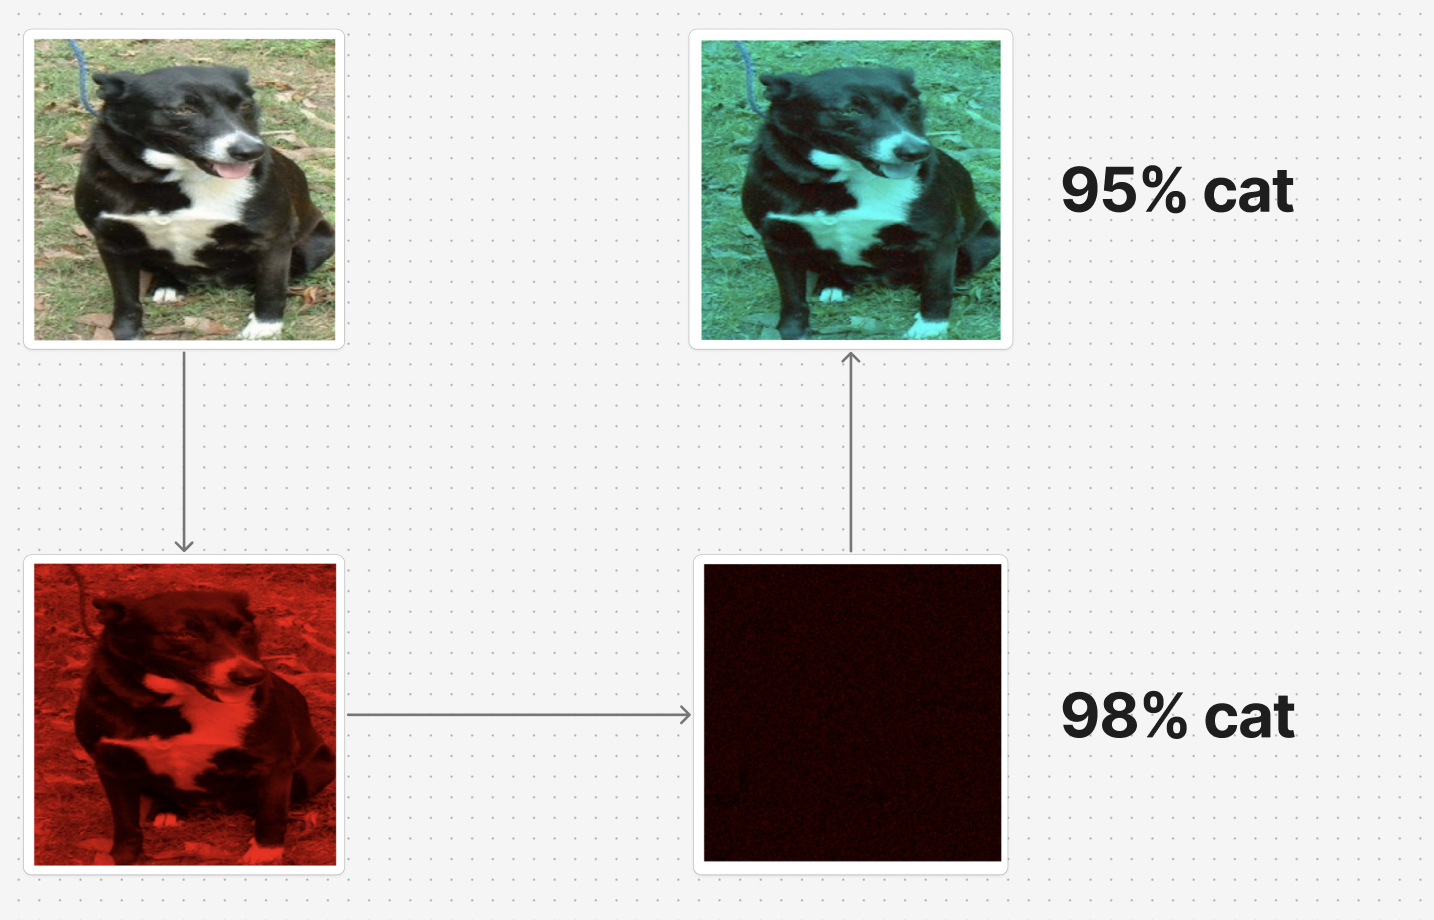

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
0
tensor([0.8914, 0.8845, 0.8814, 0.8813, 0.8825, 0.8763, 0.8755, 0.8753, 0.8737,
        0.8729, 0.8725, 0.8728, 0.8702, 0.8713, 0.8708, 0.8690, 0.8681, 0.8671,
        0.8667, 0.8665, 0.8754, 0.8674, 0.8705, 0.8664, 0.8781, 0.8705, 0.8804,
        0.8717, 0.8582, 0.8621, 0.8701, 0.8724, 0.8550, 0.8630, 0.8683, 0.8501,
        0.8581, 0.8632, 0.8592, 0.8627])
34.81217956542969
Adversarial image found!


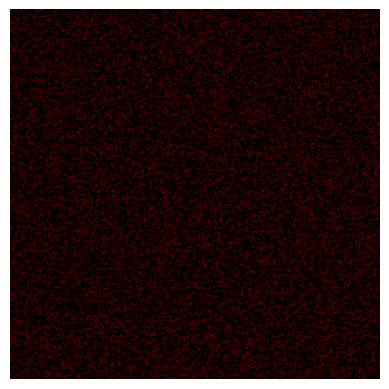

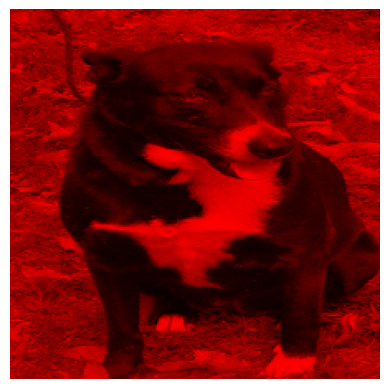

tensor([0.0003])
tensor([0.9558])


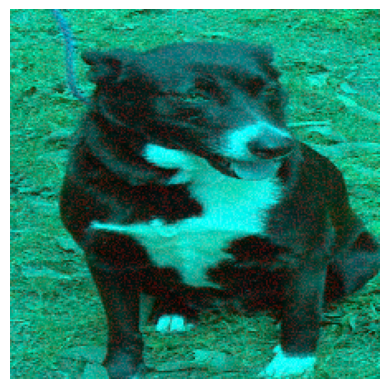

In [ ]:
# 2ND APPROACH

# NOISE VERSION
# WITH NOISE ONLY, NO IMAGES
# ⚙️ HYPERPARAMETERS

# Free GPU cache
torch.cuda.empty_cache()

ENUMS = 1000

WANTED_CLASS = 0
UNWANTED_CLASS = 1 # not used

HEIGHT = 0.15 # significantly increse running time; its the height of the crossover square

REACH = 0.3 # value added to each pixel -> -REACH <= x <= REACH
REACH_NOISE = 0.05 # to add really small mutations

MAX_POURCENTAGE = 1 # maximum number of pixels changed = MAX_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MIN_POURCENTAGE = 0.9 # minimum number of pixels changed = MIN_POURCENTAGE * total number of pixel -> 0.2 = 20% changed
MAX_POURCENTAGE_NOISE = 1

ELITES = 10

TARGETED = True
TARGETED_CHANNEL = 0

THRESHOLD = 0.98 # sucess if the image is considered (THRESHOLD*10)% of the wanted class -> 0.6 = 60% of the wanted class

# 🧑‍🎨 LOAD AND PROCESS THE BASE IMAGE

tensor_image = torch.zeros(3, 224, 224)
multiple_copies = multiple_copies_generator(tensor_image, 40)

pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE)

multiple_copies = which_pixel_generator_noise(multiple_copies, pixel_to_change, reach=REACH, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL)

# 🤖 MODEL AND SELECTION
probabilities = through_model(multiple_copies)
elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

predicted_classes = torch.argmax(probabilities, dim=-1) # return the classes that the model predicted for each image
print(predicted_classes) # Just for the visual

for i in range(ENUMS):
  print(i)

  # 👨‍💻 COMPUTE EACH SPLIT (20-20) => 40

  top_selection = torch.cat((elites_selection, middle_selection)).clone() # no need for clone here i might remove it after checking

  # 20 -> add noise
  pixel_to_change = pixel_to_change_generator(tensor_image, lower_pourcentage=MIN_POURCENTAGE, upper_pourcentage=MAX_POURCENTAGE_NOISE)
  noise_selection = which_pixel_generator_noise(top_selection, pixel_to_change, reach=REACH_NOISE, targeted=TARGETED, targeted_channel=TARGETED_CHANNEL) # must be really small -> it adds up with the iterations

  # 20 -> crossover
  parents_index = parent_generator_fixed(top_selection)
  crossed_copies = crossover_generator(top_selection, parents_index, pourcentage_height=HEIGHT)

  # 20 + 20 = 40 index
  multiple_copies = torch.cat((crossed_copies, noise_selection)) # concatenate the splits together

  # ❗️Now we have the final image set for this iteration to pass through the model!

  # 🤖 MODEL AND SELECTION
  probabilities = through_model(multiple_copies)

  probabilities_wanted = probabilities[:, WANTED_CLASS]
  print(probabilities_wanted)
  print(probabilities_wanted.sum().item())

  elites_selection, middle_selection, elites_index, elites_proba = selection(multiple_copies, probabilities, ELITES, WANTED_CLASS, UNWANTED_CLASS, wanted=True)

  # 👍 RESULTS FOUND?/ HOW GOOD ARE THEY?
  success, success_index = checker(elites_index, elites_proba, THRESHOLD)
  if success:
    print("Adversarial image found!")
    adv_image = multiple_copies[success_index]
    break

image_adv_restored = transformPIL(adv_image)
plt.imshow(image_adv_restored)
plt.axis("off")
plt.show()

tensor_image = transformTensor(image).to(device)

tensor_image_filtered = torch.zeros_like(tensor_image)
tensor_image_filtered[TARGETED_CHANNEL] = tensor_image[TARGETED_CHANNEL]

image_targeted_restored = transformPIL(tensor_image_filtered)
plt.imshow(image_targeted_restored)
plt.axis("off")
plt.show()

batch_tensor_image = tensor_image.unsqueeze(0)
probabilitiy_base_image = through_model(batch_tensor_image)
probabilitiy_wanted_base_image = probabilitiy_base_image[:, WANTED_CLASS]
print(probabilitiy_wanted_base_image)

tensor_image[TARGETED_CHANNEL] = adv_image[TARGETED_CHANNEL]
batch_tensor_image = tensor_image.unsqueeze(0)
probabilitiy_base_image = through_model(batch_tensor_image)
probabilitiy_wanted_base_image = probabilitiy_base_image[:, WANTED_CLASS]
print(probabilitiy_wanted_base_image)

image_restored = transformPIL(tensor_image)
plt.imshow(image_restored)
plt.axis("off")
plt.show()
